# Momentum Crash-Risk Scoring

Note: metrics here use a static train/test split. Walk-forward validation in walkforward.ipynb supersedes these results.

### Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### DataFrame Import

In [12]:
df = pd.read_pickle('momentum_df.pkl')

df.head()

,Mom,Mkt-RF,SMB,HML,RF,VIX,VIX_lag,RealVol,RealVol_lag,Mkt12m,Mkt12m_lag,MomRecent,MomRecent_lag,Excess_Returns
2000-01-01,0.0186,-0.0474,0.0516,-0.0112,0.0041,24.95,24.64,0.077962,NaN,NaN,NaN,NaN,NaN,0.0145
2000-02-01,0.1802,0.0246,0.2125,-0.0977,0.0043,23.37,24.95,0.054776,0.077962,NaN,NaN,NaN,NaN,0.1759
2000-03-01,-0.0685,0.0521,-0.1741,0.0850,0.0047,24.11,23.37,0.077523,0.054776,NaN,NaN,NaN,NaN,-0.0732
2000-04-01,-0.0860,-0.0639,-0.0600,0.0645,0.0046,26.20,24.11,0.113517,0.077523,NaN,NaN,NaN,NaN,-0.0906
2000-05-01,-0.0899,-0.0439,-0.0608,0.0459,0.0050,23.65,26.20,0.081499,0.113517,NaN,NaN,NaN,NaN,-0.0949


### Z-Scoring

In [13]:
# Define Windows and Signals

train = df['2000':'2009']
test = df['2010':'2024']
full = df['2000':'2024']

signals = ['VIX_lag', 'Mkt12m_lag']

In [14]:
zscores = {}
for signal in signals:
    train_mean = train[signal].mean()
    train_std = train[signal].std()
    zscores[signal] = [train_mean, train_std]

for signal, vals in zscores.items():
    name = signal + "_z"
    df[name] = (df[signal] - vals[0]) / vals[1]

df['Mkt12m_lag_z'] = -df['Mkt12m_lag_z']

df['risk_score'] = 0.5 * df['VIX_lag_z'] + 0.5 * df['Mkt12m_lag_z']

df.head()
df.tail()

,Mom,Mkt-RF,SMB,HML,RF,VIX,VIX_lag,RealVol,RealVol_lag,Mkt12m,Mkt12m_lag,MomRecent,MomRecent_lag,Excess_Returns,VIX_lag_z,Mkt12m_lag_z,risk_score
2024-08-01,0.0481,0.0160,-0.0349,-0.0110,0.0048,15.00,16.36,0.059261,0.041943,0.264151,0.214739,0.022803,0.023681,0.0433,-0.607986,-1.147796,-0.877891
2024-09-01,-0.0062,0.0172,-0.0013,-0.0277,0.0040,16.73,15.00,0.041748,0.059261,0.356041,0.264151,0.019725,0.022803,-0.0102,-0.756577,-1.406307,-1.081442
2024-10-01,0.0300,-0.0100,-0.0099,0.0086,0.0039,23.16,16.73,0.032164,0.041748,0.384884,0.356041,0.054852,0.019725,0.0261,-0.567560,-1.887052,-1.227306
2024-11-01,0.0100,0.0649,0.0446,0.0015,0.0040,13.51,23.16,0.038848,0.032164,0.354100,0.384884,0.067108,0.054852,0.0060,0.134970,-2.037951,-0.951491
2024-12-01,-0.0030,-0.0317,-0.0271,-0.0300,0.0037,17.35,13.51,0.043631,0.038848,0.250176,0.354100,0.054940,0.067108,-0.0067,-0.919372,-1.876899,-1.398135


In [15]:
train_scores = df.loc['2000':'2009', 'risk_score']

### Dynamic Mapping and Scaling

In [16]:
p_lo = df.loc['2000':'2009', 'risk_score'].quantile(0.10)
p_hi = df.loc['2000':'2009', 'risk_score'].quantile(0.90)

df['exposure'] = 1 - (df['risk_score'] - p_lo) / (p_hi - p_lo)
df['exposure'] = df['exposure'].clip(0, 1)

df['Dynamic Returns'] = df['exposure'] * df['Mom']
df['Dynamic Excess Returns'] = df['exposure'] * (df['Mom'] - df['RF'])

In [17]:
# Verify exposure is bounded [0, 1]
df['exposure'] = df['exposure'].fillna(0)
assert df['exposure'].between(0, 1).all(), "Exposure out of bounds"

# Verify directionality: high risk score → low exposure
high_risk = df.nlargest(10, 'risk_score')['exposure']
print("Exposure at highest risk scores (should be near 0):")
print(high_risk.values)

Exposure at highest risk scores (should be near 0):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Backtesting and Metrics Comparison

In [18]:
windows = {'Full': ('2000', '2024'), 'Train': ('2000', '2009'), 'Test': ('2010', '2024')}

print("=== BASELINE ===")
for label, (start, end) in windows.items():
    subset = df.loc[start:end]
    excess = subset['Mom'] - subset['RF']
    sharpe = (excess.mean() / excess.std()) * np.sqrt(12)
    downside_dev = np.sqrt(np.mean(np.minimum(excess, 0)**2))
    sortino = (excess.mean() / downside_dev) * np.sqrt(12)
    cumulative = (1 + subset['Mom']).cumprod()
    drawdown = (cumulative - cumulative.cummax()) / cumulative.cummax()
    max_dd = drawdown.min()
    print(f"\n{label} ({start}–{end})")
    print(f"  Sharpe: {sharpe:.3f} | Sortino: {sortino:.3f} | Max DD: {max_dd:.3f}")

print("\n=== STATIC 50% ===")
for label, (start, end) in windows.items():
    subset = df.loc[start:end]
    excess = 0.5 * (subset['Mom'] - subset['RF'])
    sharpe = (excess.mean() / excess.std()) * np.sqrt(12)
    downside_dev = np.sqrt(np.mean(np.minimum(excess, 0)**2))
    sortino = (excess.mean() / downside_dev) * np.sqrt(12)
    cumulative = (1 + 0.5 * subset['Mom']).cumprod()
    drawdown = (cumulative - cumulative.cummax()) / cumulative.cummax()
    max_dd = drawdown.min()
    print(f"\n{label} ({start}–{end})")
    print(f"  Sharpe: {sharpe:.3f} | Sortino: {sortino:.3f} | Max DD: {max_dd:.3f}")

print("\n=== DYNAMIC ===")
for label, (start, end) in windows.items():
    subset = df.loc[start:end]
    excess = subset['Dynamic Excess Returns']
    sharpe = (excess.mean() / excess.std()) * np.sqrt(12)
    downside_dev = np.sqrt(np.mean(np.minimum(excess, 0)**2))
    sortino = (excess.mean() / downside_dev) * np.sqrt(12)
    cumulative = (1 + subset['Dynamic Excess Returns']).cumprod()
    drawdown = (cumulative - cumulative.cummax()) / cumulative.cummax()
    max_dd = drawdown.min()
    print(f"\n{label} ({start}–{end})")
    print(f"  Sharpe: {sharpe:.3f} | Sortino: {sortino:.3f} | Max DD: {max_dd:.3f}")

=== BASELINE ===

Full (2000–2024)
  Sharpe: 0.022 | Sortino: 0.028 | Max DD: -0.578

Train (2000–2009)
  Sharpe: -0.074 | Sortino: -0.093 | Max DD: -0.578

Test (2010–2024)
  Sharpe: 0.147 | Sortino: 0.199 | Max DD: -0.254

=== STATIC 50% ===

Full (2000–2024)
  Sharpe: 0.022 | Sortino: 0.028 | Max DD: -0.331

Train (2000–2009)
  Sharpe: -0.074 | Sortino: -0.093 | Max DD: -0.331

Test (2010–2024)
  Sharpe: 0.147 | Sortino: 0.199 | Max DD: -0.133

=== DYNAMIC ===

Full (2000–2024)
  Sharpe: 0.362 | Sortino: 0.549 | Max DD: -0.162

Train (2000–2009)
  Sharpe: 0.391 | Sortino: 0.589 | Max DD: -0.134

Test (2010–2024)
  Sharpe: 0.345 | Sortino: 0.527 | Max DD: -0.162


In [19]:
# Transaction Costs

windows = {'Full': ('2000', '2024'), 'Train': ('2000', '2009'), 'Test': ('2010', '2024')}

for cost in [0, 0.001, 0.002, 0.005]:
    turnover = df['exposure'].diff().abs().fillna(0)
    df['Dynamic Excess Returns Net'] = df['Dynamic Excess Returns'] - cost * turnover
    
    print(f"\n=== COST = {cost*10000:.0f} bps ===")
    for label, (start, end) in windows.items():
        subset = df.loc[start:end]
        excess = subset['Dynamic Excess Returns Net']
        sharpe = (excess.mean() / excess.std()) * np.sqrt(12)
        print(f"  {label}: Sharpe {sharpe:.3f}")


=== COST = 0 bps ===
  Full: Sharpe 0.362
  Train: Sharpe 0.391
  Test: Sharpe 0.345

=== COST = 10 bps ===
  Full: Sharpe 0.346
  Train: Sharpe 0.378
  Test: Sharpe 0.329

=== COST = 20 bps ===
  Full: Sharpe 0.331
  Train: Sharpe 0.364
  Test: Sharpe 0.313

=== COST = 50 bps ===
  Full: Sharpe 0.286
  Train: Sharpe 0.323
  Test: Sharpe 0.265


### Risk Score Plot

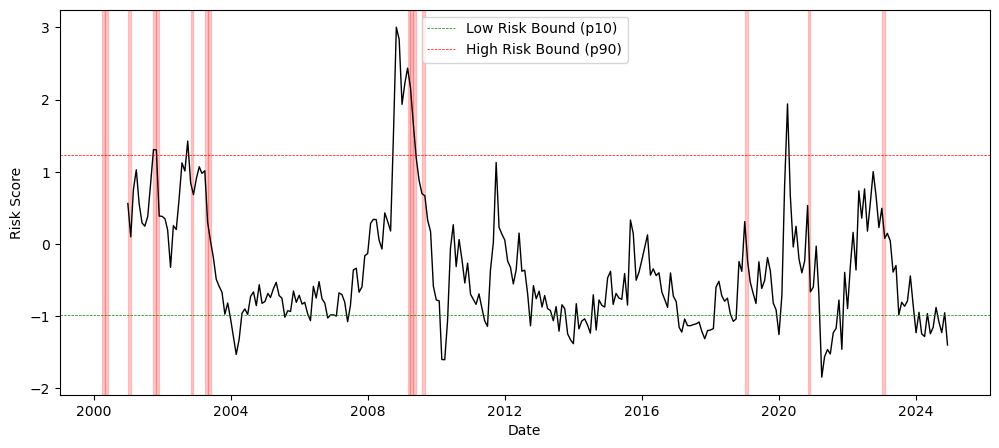

In [20]:
crash_threshold = df['2000':'2009']['Mom'].quantile(0.10)
crash_months = df[df['Mom'] <= crash_threshold].index

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['risk_score'], color='black', linewidth=1)
plt.xlabel("Date")
plt.ylabel('Risk Score')
plt.axhline(y=p_lo, color='green', linestyle='--', linewidth=0.5, label="Low Risk Bound (p10)")
plt.axhline(y=p_hi, color='red', linestyle='--', linewidth=0.5, label="High Risk Bound (p90)")
for date in crash_months:
        plt.axvspan(date, date + pd.DateOffset(months=1), color='red', alpha=0.2)
plt.legend()
plt.show()

### Key Findings and Summary

#### Methodology
- Despite findings Daniel and Moskowitz (2016), Welch's t-test found lagged 6-month momentum to not be a significant signal (t = -0.60, p = 0.56) for bottom 10th percentile of momentum strategy returns through training window t-tests.
- Z-Scores for each signal were calculated using only training window parameters.
- Joint logistic regression revealed RealVol_lag to add no independent predictive power beyond VIX_lag (p-value = 0.952).
- Two signal model using VIX_lag and Mkt12m_lag selected on the basis at equal weight.
- Exposure is scaled continuously using training window p10/p90 bounds: exposure = 1 − (risk_score − p10) / (p90 − p10), clipped to [0, 1]. High risk score → low exposure.

#### Results
- OOS Sharpe: Baseline 0.147 | Static 50% 0.147 | Dynamic 0.345
- OOS Sortino: Baseline 0.199 | Static 50% 0.199 | Dynamic 0.527
- OOS Max Drawdown: Baseline -0.254 | Static 50% -0.133 | Dynamic -0.162
- OOS Sharpe at 50bps transaction cost: 0.240

#### Limitations
- Static single train/test split (walk-forward validation in walforward.ipynb)
- Transaction cost model applies cost to overlay weight changes, not underlying long-short portfolio turnover
- Post-2009 structural break in momentum means OOS regime differs from training regime
- UMD is not directly tradeable. Real implementation requires trading the long-short equity book, which carries higher transaction costs and capacity constraints than the overlay model captures.